# Reeks 2: oefening 1
Importeer externe software bibliotheken, bijvoorbeeld om snel operaties te doen op matrices en vectoren (numpy) of om figuren te maken (matplotlib).


In [1]:
# Jan Ryckebusch, Octber 2017
# Tom Vieijra, October 2018
# 
# Python routine that comes with Problem 1 of Series 2
# [can be used as a template for many other problems ...]
# illustrates the use of the module numpy and 
# and the use of matplotlib for creating xy plots
#
# ** Two-dimensional paramagnetism for a system of quantized
#                magnetic moments **
import numpy as np   # numerical python: very fast computing
import matplotlib.pyplot as plt # matplotlib: nice & quick figures


Definieer een functie die een lijst teruggeeft met alle mogelijke waarden die de hoek $\theta$ kan aannemen.

In [2]:
# function that creates a list of angles  
def create_list_of_theta(jj):
    twopi=2.*np.pi
    tlist=np.linspace(twopi/jj,twopi,jj,endpoint=True)
    return tlist


Definieer een functie die, gegeven een set temperaturen (xvalues) en de mogelijke waarden voor $\theta$ (tlist), voor elke temperatuur de gemiddelde magnetisatie in zowel de $x$ als $y$-richting, de susceptibiliteit en de entropie berekent.

In [3]:
# function that computes 
#    i) the partition function
#    ii) the magnetizations along x and y
#    iii) the susceptibility 
#    iv) the entropy
# x = m \mathcal{B}  / k T (dimensionless quantity)
def create_the_obser(xvalues, tlist):
    Z1=np.zeros_like(xvalues) # partition function
    MX=np.zeros_like(xvalues) # magnetization along x
    MY=np.zeros_like(xvalues) # magnetization along y
    M2X=np.zeros_like(xvalues) # squared magnetization along x
    magneX=np.zeros_like(xvalues)
    magneY=np.zeros_like(xvalues)
    suscep=np.zeros_like(xvalues)
    entrop=np.zeros_like(xvalues)
    for t in tlist:
        Z1+=np.exp(xvalues*np.cos(t))
        MX+=np.cos(t)*np.exp(xvalues*np.cos(t))
        MY+=np.sin(t)*np.exp(xvalues*np.cos(t))
        M2X+=np.power(np.cos(t),2)*np.exp(xvalues*np.cos(t))
    magneX=np.divide(MX,Z1) # \mathcal{M}_x/ (N m)
    magneY=np.divide(MY,Z1) # \mathcal{M}_y/ (N m)
    suscep=np.divide(M2X,Z1)-np.power(magneX,2)
# S = (E-F) / T 
# F = -k T log Z ---> F [ in units m \mathcal{B}] = - k T log Z /x 
# E = -magnetization / \mid \vec{B} \mid
# S (in units k) = log Z + x E 
    entrop=np.add(np.log(Z1),np.multiply(xvalues,-magneX))
    return magneX,magneY,suscep,entrop


Voer de functie uit. Hiervoor worden de lijsten met waarden voor $\theta$ en een set van temperaturen gegenereerd en de bovenstaande functie opgeroepen.

In [4]:
# MAIN PROGRAM
# STEP1: create the arrays with  angles
listt3=create_list_of_theta(3) # 3 directions (120, 240, 360 degrees)
listt6=create_list_of_theta(6) # 6 directions (60, 120, 180, ..., 360 degrees)
listt12=create_list_of_theta(12) # 12 directions (30, 60, ... , 360 degrees)
listt24=create_list_of_theta(24) # 24 directions (15, 30, ... , 360 degrees)
# an array with x values: x = \mu \mathcal{B} / k T
#print listt12
number_of_xvalues=300
xvalues=np.linspace(0.,+10.,number_of_xvalues,endpoint=True)
#
# STEP2: create the list of observables (magnetization, susceptibility, entropy)
magneX1,magneY1,suscep1,entrop1=create_the_obser(xvalues,listt3)
magneX2,magneY2,suscep2,entrop2=create_the_obser(xvalues,listt6)
magneX3,magneY3,suscep3,entrop3=create_the_obser(xvalues,listt12)
magneX4,magneY4,suscep4,entrop4=create_the_obser(xvalues,listt24)


Genereer de figuren: de magnetisatie in de $x$-richting in functie van de dimensieloze grootheid $x=(m \mid \vec{\mathcal{B}} \mid) / (k T)$, de susceptibiliteit in functie van $x$ en de entropie in functie van $\frac{1}{x}$.

/home/tom/.local/lib/python3.6/site-packages/ipykernel_launcher.py:58: RuntimeWarning: divide by zero encountered in true_divide
/home/tom/.local/lib/python3.6/site-packages/ipykernel_launcher.py:59: RuntimeWarning: divide by zero encountered in true_divide


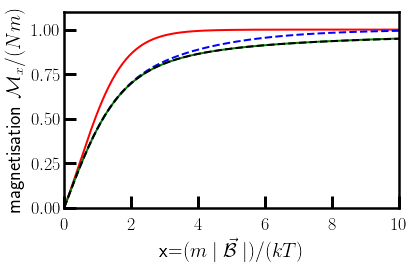

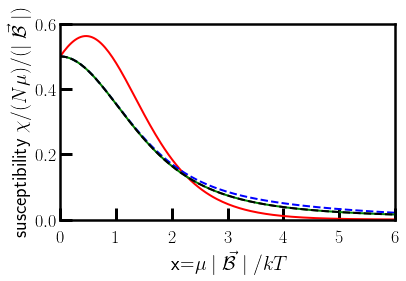

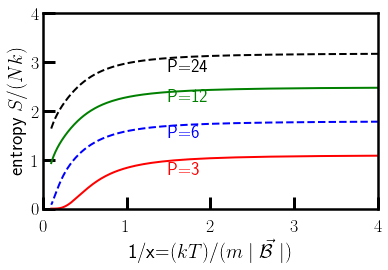

In [5]:
# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
# comment this out when facing problems under Python 3
params = {'legend.fontsize' : 20,
#          'legend.linewidth': 2, TROUBLESOME ....
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2,
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams.update(params)
#----------------------------------------------------------------------
#
# create the plots in matplotlib
# first figure: the magnetization along x
fig=plt.figure(1)
ax=fig.add_subplot(111)
fig.subplots_adjust(bottom=0.2) # create room for x-axis label
#
ax.axis([0.,10.,0.,1.1])
ax.set_xlabel(r' x=$(m \mid \vec{\mathcal{B}} \mid) / (k T)$')
ax.set_ylabel(r' magnetisation $\mathcal{M}_x / (N m)$')
ax.plot(xvalues, magneX1, 'r-', xvalues, magneX2, 'b--', xvalues, magneX3, 'g-',xvalues,magneX4,'k--')
fig.savefig('MagnetizationAlongxR2O1.eps')
fig.savefig('MagnetizationAlongxR2O1.png')
#
# second figure with susceptibility
#
fig2=plt.figure(2)
ax2=fig2.add_subplot(111)
fig2.subplots_adjust(bottom=0.2) # create room for x-axis label
#
ax2.axis([0.,6.,0.,.6])
ax2.set_xlabel(r' x=$\mu \mid \vec{\mathcal{B}} \mid / k T$')
ax2.set_ylabel(r' susceptibility $ \chi / (N \mu ) / (\mid \vec{\mathcal{B}} \mid) $')
ax2.plot(xvalues, suscep1, 'r-', xvalues, suscep2, 'b--', xvalues, suscep3, 'g-',xvalues,suscep4,'k--')
fig2.savefig('SusceptibilityR2O1.eps')
fig2.savefig('SusceptibilityR2O1.png')
#
# third figure with entropy as a function of 1/x
#
fig3=plt.figure(3)
ax3=fig3.add_subplot(111)
fig3.subplots_adjust(bottom=0.2) # create room for x-axis label
#
ax3.axis([0.,4.,0.,4.])
ax3.set_xlabel(r' 1/x=$(k T ) / (m \mid \vec{\mathcal{B}} \mid) $')
ax3.set_ylabel(r' entropy $S /(Nk)$ ')
ax3.plot(1./xvalues, entrop1, 'r-', 1./xvalues, entrop2, 'b--', 1./xvalues,
       entrop3, 'g-',1./xvalues,entrop4,'k--')
ax3.text(1.5, 0.7,' P=3',color='red',fontsize=18,fontweight='bold')
ax3.text(1.5, 1.45,' P=6',color='blue',fontsize=18,fontweight='bold')
ax3.text(1.5, 2.2,' P=12',color='green',fontsize=18,fontweight='bold')
ax3.text(1.5, 2.8,' P=24',color='black',fontsize=18,fontweight='bold')
fig3.savefig('EntropyR2O1.eps')
fig3.savefig('EntropyR2O1.png')
#
#

plt.show()
